In [ ]:
!pip install xgboost pandas scikit-learn matplotlib joblib

In [ ]:
import pandas as pd

df = pd.read_csv("All_Players_1992-2025.csv", low_memory=False)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 92170
Columns: 120


,PlayerID,Player,Squad,League,Nation,Pos,Age,Born,Season,MP,...,The Best FIFA Mens Player,UEFA Best Player,UCL_MP,UCL_Gls,UCL_xG,UCL_Ast,UCL_xA,UCL_KP,UCL_GCA,UCL_SCA
0,4,Alexander Strehmel,Stuttgart,Bundesliga,GER,"DF,MF",24.0,1968.0,1992-1993,20.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,Alexander Strehmel,Stuttgart,Bundesliga,GER,"DF,MF",25.0,1968.0,1993-1994,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,Alexander Strehmel,Unterhaching,Bundesliga,GER,"DF,MF",31.0,1968.0,1999-2000,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Alexander Strehmel,Unterhaching,Bundesliga,GER,"DF,MF",32.0,1968.0,2000-2001,32.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,Alois Reinhardt,Bayern Munich,Bundesliga,GER,DF,30.0,1961.0,1992-1993,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("SEASONS:")
print(sorted(df["Season"].dropna().unique()))

print("\nPOSITIONS:")
print(df["Pos"].value_counts().head(20))

print("\nLEAGUES:")
print(df["League"].value_counts())

SEASONS:
['1992-1993', '1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']

POSITIONS:
Pos
DF       25239
MF       22568
FW       13456
FW,MF    10083
GK        8809
DF,MF     8039
MF,FW     1986
DF,FW     1258
MF,DF      546
FW,DF      181
FW,GK        4
DF,GK        1
Name: count, dtype: int64

LEAGUES:
League
Serie A           19761
Premier League    19317
La Liga           19118
Ligue 1           17331
Bundesliga        16643
Name: count, dtype: int64


In [ ]:
# Select the seasons we want
selected_seasons = [
    "2017-2018",
    "2018-2019",
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
    "2024-2025"
]

df_ml = df[df["Season"].isin(selected_seasons)].copy()

# Assign a primary position
# If a player has multiple positions, use the first listed position
df_ml["PosGroup"] = df_ml["Pos"].fillna("").str.split(",").str[0]

# Keep only forwards, midfielders and defenders
df_ml = df_ml[df_ml["PosGroup"].isin(["FW", "MF", "DF"])].copy()

print("After filtering:")
print("Rows:", len(df_ml))
print("\nPosition distribution:")
print(df_ml["PosGroup"].value_counts())

print("\nSeason distribution:")
print(df_ml["Season"].value_counts().sort_index())

After filtering:
Rows: 24034

Position distribution:
PosGroup
DF    9338
MF    8380
FW    6316
Name: count, dtype: int64

Season distribution:
Season
2017-2018    2815
2018-2019    2760
2019-2020    2884
2020-2021    3052
2021-2022    3189
2022-2023    3124
2023-2024    3113
2024-2025    3097
Name: count, dtype: int64


In [ ]:
# Important football performance columns
performance_columns = [
    "Gls", "Ast", "xG", "xA",
    "Sh", "SoT",
    "KP", "SCA",
    "PrgC", "PrgP", "PrgR",
    "Tkl", "TklW", "Int",
    "Clr", "Blocks",
    "Won", "Won%",
    "Min", "90s",
    "Carries", "Rec",
    "Att Pen"
]

# Show which columns actually exist in our dataset
available = [col for col in performance_columns if col in df_ml.columns]
missing = [col for col in performance_columns if col not in df_ml.columns]

print("AVAILABLE PERFORMANCE COLUMNS:")
print(available)

print("\nMISSING COLUMNS:")
print(missing)

print("\nDATA TYPES:")
print(df_ml[available].dtypes)

AVAILABLE PERFORMANCE COLUMNS:
['Gls', 'Ast', 'xG', 'xA', 'Sh', 'SoT', 'KP', 'SCA', 'PrgC', 'PrgP', 'PrgR', 'Tkl', 'TklW', 'Int', 'Clr', 'Blocks', 'Won', 'Won%', 'Min', '90s', 'Carries', 'Rec', 'Att Pen']

MISSING COLUMNS:
[]

DATA TYPES:
Gls        float64
Ast        float64
xG         float64
xA         float64
Sh         float64
SoT        float64
KP         float64
SCA        float64
PrgC       float64
PrgP       float64
PrgR       float64
Tkl        float64
TklW       float64
Int        float64
Clr        float64
Blocks     float64
Won        float64
Won%       float64
Min        float64
90s        float64
Carries    float64
Rec        float64
Att Pen    float64
dtype: object


In [ ]:
import numpy as np

# Keep players with enough playing time
df_ml = df_ml[df_ml["Min"] >= 450].copy()

# Avoid division by zero
df_ml["90s"] = df_ml["90s"].replace(0, np.nan)

# Convert important statistics to per-90 values
per90_columns = [
    "Gls", "xG", "Ast", "xA",
    "KP", "SCA",
    "PrgC", "PrgP",
    "TklW", "Int", "Clr", "Blocks",
    "Tkl"
]

for col in per90_columns:
    df_ml[col + "_90"] = df_ml[col] / df_ml["90s"]

# Create combined defensive actions per 90
df_ml["TklInt_90"] = (df_ml["Tkl"] + df_ml["Int"]) / df_ml["90s"]

# Make sure aerial-duel percentage is numeric
df_ml["WonPct_num"] = pd.to_numeric(df_ml["Won%"], errors="coerce")

print("Players after 450-minute filter:", len(df_ml))

print("\nMissing values in score variables:")
score_check = [
    "Gls_90", "xG_90", "Ast_90", "xA_90",
    "KP_90", "SCA_90", "PrgC_90", "PrgP_90",
    "TklW_90", "Int_90", "Clr_90",
    "Blocks_90", "TklInt_90", "WonPct_num"
]

print(df_ml[score_check].isna().sum())

Players after 450-minute filter: 14812

Missing values in score variables:
Gls_90        0
xG_90         0
Ast_90        0
xA_90         0
KP_90         0
SCA_90        0
PrgC_90       0
PrgP_90       0
TklW_90       0
Int_90        0
Clr_90        0
Blocks_90     0
TklInt_90     0
WonPct_num    0
dtype: int64


In [ ]:
# ==========================================
# STEP 6: POSITION-SPECIFIC PERFORMANCE SCORE
# ==========================================

# Function to convert a statistic into a percentile
# within the same position and season.
def percentile_by_position_season(df, column):
    return (
        df.groupby(["PosGroup", "Season"])[column]
        .rank(pct=True)
    )


# Create percentile versions of our performance statistics
score_features = [
    "Gls_90",
    "xG_90",
    "Ast_90",
    "xA_90",
    "KP_90",
    "SCA_90",
    "PrgC_90",
    "PrgP_90",
    "TklW_90",
    "Int_90",
    "Clr_90",
    "Blocks_90",
    "TklInt_90",
    "WonPct_num"
]

for feature in score_features:
    df_ml[feature + "_pct"] = percentile_by_position_season(
        df_ml, feature
    )


# ------------------------------------------
# FORWARD SCORE
# ------------------------------------------

fw_mask = df_ml["PosGroup"] == "FW"

df_ml.loc[fw_mask, "PerformanceScore"] = (
    0.25 * df_ml.loc[fw_mask, "Gls_90_pct"] +
    0.20 * df_ml.loc[fw_mask, "xG_90_pct"] +
    0.15 * df_ml.loc[fw_mask, "Ast_90_pct"] +
    0.15 * df_ml.loc[fw_mask, "xA_90_pct"] +
    0.15 * df_ml.loc[fw_mask, "SCA_90_pct"] +
    0.10 * df_ml.loc[fw_mask, "PrgC_90_pct"]
)


# ------------------------------------------
# MIDFIELDER SCORE
# ------------------------------------------

mf_mask = df_ml["PosGroup"] == "MF"

df_ml.loc[mf_mask, "PerformanceScore"] = (
    0.15 * df_ml.loc[mf_mask, "Ast_90_pct"] +
    0.15 * df_ml.loc[mf_mask, "xA_90_pct"] +
    0.15 * df_ml.loc[mf_mask, "KP_90_pct"] +
    0.20 * df_ml.loc[mf_mask, "PrgP_90_pct"] +
    0.15 * df_ml.loc[mf_mask, "SCA_90_pct"] +
    0.10 * df_ml.loc[mf_mask, "TklW_90_pct"] +
    0.10 * df_ml.loc[mf_mask, "Int_90_pct"]
)


# ------------------------------------------
# DEFENDER SCORE
# ------------------------------------------

df_mask = df_ml["PosGroup"] == "DF"

df_ml.loc[df_mask, "PerformanceScore"] = (
    0.25 * df_ml.loc[df_mask, "TklInt_90_pct"] +
    0.15 * df_ml.loc[df_mask, "Clr_90_pct"] +
    0.10 * df_ml.loc[df_mask, "Blocks_90_pct"] +
    0.15 * df_ml.loc[df_mask, "WonPct_num_pct"] +
    0.15 * df_ml.loc[df_mask, "PrgP_90_pct"] +
    0.10 * df_ml.loc[df_mask, "PrgC_90_pct"] +
    0.10 * df_ml.loc[df_mask, "SCA_90_pct"]
)


# Convert 0–1 score into 0–100
df_ml["PerformanceScore"] = df_ml["PerformanceScore"] * 100


# Check the results
print("Performance score created successfully!\n")

print(df_ml[
    ["Player", "Season", "PosGroup", "PerformanceScore"]
].head(20))

Performance score created successfully!

                 Player     Season PosGroup  PerformanceScore
5504    Claudio Pizarro  2017-2018       FW         48.808204
5513    Claudio Pizarro  2018-2019       FW         68.923077
7661       Daniel Baier  2017-2018       MF         64.980710
7662       Daniel Baier  2018-2019       MF         45.926217
7663       Daniel Baier  2019-2020       MF         25.188088
7895        Mario Gómez  2017-2018       FW         52.644124
7896        Mario Gómez  2018-2019       FW         37.186813
7898        Mario Gómez  2017-2018       FW         40.670732
7926   Matthias Lehmann  2017-2018       MF         34.749228
8139         Aaron Hunt  2017-2018       MF         68.518519
8196  Christian Gentner  2017-2018       MF         57.777778
8197  Christian Gentner  2018-2019       MF         63.995290
8198  Christian Gentner  2019-2020       MF         50.411442
8199  Christian Gentner  2020-2021       MF         36.402157
8276        Dennis Aogo  2017

In [ ]:
# Find players who appear more than once in the same season

duplicates = (
    df_ml.groupby(["PlayerID", "Player", "Season"])
    .size()
    .reset_index(name="NumberOfRows")
)

duplicates = duplicates[duplicates["NumberOfRows"] > 1]

print("Duplicate player-season combinations:", len(duplicates))

duplicates.head(20)

Duplicate player-season combinations: 223


,PlayerID,Player,Season,NumberOfRows
5,2190,Mario Gómez,2017-2018,2
123,2710,Max Kruse,2021-2022,2
127,2732,Sandro Wagner,2017-2018,2
167,2815,Kevin Vogt,2019-2020,2
171,2815,Kevin Vogt,2023-2024,2
426,3144,Simon Terodde,2017-2018,2
498,3210,Jeffrey Bruma,2019-2020,2
722,3353,Marc-Oliver Kempf,2021-2022,2
832,3425,Davie Selke,2019-2020,2
866,3441,Henrikh Mkhitaryan,2017-2018,2


In [ ]:
# Inspect one of the duplicate player-season cases

example = df_ml[
    (df_ml["PlayerID"] == 2190) &
    (df_ml["Season"] == "2017-2018")
].copy()

display(
    example[
        [
            "PlayerID",
            "Player",
            "Squad",
            "League",
            "Season",
            "MP",
            "Min",
            "Gls",
            "Ast",
            "xG",
            "xA",
            "Sh",
            "SoT",
            "KP",
            "SCA",
            "PrgC",
            "PrgP"
        ]
    ]
)

,PlayerID,Player,Squad,League,Season,MP,Min,Gls,Ast,xG,xA,Sh,SoT,KP,SCA,PrgC,PrgP
7895,2190,Mario Gómez,Stuttgart,Bundesliga,2017-2018,16.0,1385.0,8.0,0.0,5.7,2.3,0.0,15.0,14.0,30.0,19.0,31.0
7898,2190,Mario Gómez,Wolfsburg,Bundesliga,2017-2018,12.0,936.0,1.0,2.0,4.4,1.0,1.0,7.0,11.0,21.0,6.0,14.0


In [ ]:
# ==========================================
# STEP 7: COMBINE CLUBS FOR THE SAME
# PLAYER IN THE SAME SEASON
# ==========================================

# Statistics that should be added when a player
# played for multiple clubs in the same season.
sum_columns = [
    "MP", "Min",
    "Gls", "Ast", "xG", "xA",
    "Sh", "SoT", "KP", "SCA",
    "PrgC", "PrgP", "PrgR",
    "Tkl", "TklW", "Int",
    "Clr", "Blocks", "Won", "Att Pen"
]

# Keep only columns that exist
sum_columns = [c for c in sum_columns if c in df_ml.columns]

# Information that remains the same for a player-season
first_columns = [
    "PlayerID",
    "Player",
    "Nation",
    "Pos",
    "Age",
    "Born",
    "Season",
    "PosGroup"
]

first_columns = [c for c in first_columns if c in df_ml.columns]

# Create aggregation rules
aggregation = {}

for col in first_columns:
    aggregation[col] = "first"

for col in sum_columns:
    aggregation[col] = "sum"

# Combine clubs
df_player = (
    df_ml
    .groupby(["PlayerID", "Season"], as_index=False)
    .agg(aggregation)
)

# Recalculate 90s from total minutes
df_player["90s"] = df_player["Min"] / 90

print("Original player-club rows:", len(df_ml))
print("Final player-season rows:", len(df_player))

# Check whether duplicates remain
duplicate_count = (
    df_player
    .groupby(["PlayerID", "Season"])
    .size()
    .gt(1)
    .sum()
)

print("Remaining duplicate player-seasons:", duplicate_count)

# Check Mario Gómez
print("\nMario Gómez — 2017-2018:")

display(
    df_player[
        (df_player["PlayerID"] == 2190) &
        (df_player["Season"] == "2017-2018")
    ][[
        "PlayerID",
        "Player",
        "Season",
        "Min",
        "Gls",
        "Ast",
        "xG",
        "xA",
        "Sh",
        "SoT",
        "KP",
        "SCA",
        "PrgC",
        "PrgP"
    ]]
)

Original player-club rows: 14812
Final player-season rows: 14589
Remaining duplicate player-seasons: 0

Mario Gómez — 2017-2018:


,PlayerID,Player,Season,Min,Gls,Ast,xG,xA,Sh,SoT,KP,SCA,PrgC,PrgP
5,2190,Mario Gómez,2017-2018,2321.0,9.0,2.0,10.1,3.3,1.0,22.0,25.0,51.0,25.0,45.0


In [ ]:
# ==========================================
# STEP 8: RECALCULATE PER-90 STATISTICS
# ==========================================

# Recalculate 90-minute units
df_player["90s"] = df_player["Min"] / 90

# Avoid division by zero
df_player["90s"] = df_player["90s"].replace(0, np.nan)

# Statistics that will be converted to per-90
per90_columns = [
    "Gls",
    "xG",
    "Ast",
    "xA",
    "KP",
    "SCA",
    "PrgC",
    "PrgP",
    "PrgR",
    "Tkl",
    "TklW",
    "Int",
    "Clr",
    "Blocks"
]

for col in per90_columns:
    df_player[col + "_90"] = df_player[col] / df_player["90s"]

# Combined defensive actions
df_player["TklInt_90"] = (
    df_player["Tkl"] + df_player["Int"]
) / df_player["90s"]

print("Per-90 statistics recalculated successfully!")

display(
    df_player[
        [
            "Player",
            "Season",
            "PosGroup",
            "Min",
            "Gls_90",
            "xG_90",
            "Ast_90",
            "xA_90",
            "KP_90",
            "PrgP_90",
            "TklInt_90"
        ]
    ].head(15)
)

Per-90 statistics recalculated successfully!


,Player,Season,PosGroup,Min,Gls_90,xG_90,Ast_90,xA_90,KP_90,PrgP_90,TklInt_90
0,Claudio Pizarro,2017-2018,FW,579.0,0.155440,0.295337,0.155440,0.186528,1.243523,4.041451,2.176166
1,Claudio Pizarro,2018-2019,FW,692.0,0.650289,0.403179,0.260116,0.104046,1.300578,3.381503,1.430636
2,Daniel Baier,2017-2018,MF,2538.0,0.000000,0.031915,0.070922,0.088652,0.957447,6.985816,4.964539
3,Daniel Baier,2018-2019,MF,2815.0,0.000000,0.028774,0.031972,0.038366,0.703375,5.978686,3.900533
4,Daniel Baier,2019-2020,MF,1941.0,0.046368,0.023184,0.000000,0.023184,0.463679,3.570325,4.219474
5,Mario Gómez,2017-2018,FW,2321.0,0.348988,0.391642,0.077553,0.127962,0.969410,1.744938,0.891857
6,Mario Gómez,2018-2019,FW,2211.0,0.284939,0.378562,0.081411,0.056988,1.017639,1.506106,0.976934
7,Matthias Lehmann,2017-2018,MF,1515.0,0.000000,0.017822,0.000000,0.035644,0.178218,7.069307,3.504950
8,Aaron Hunt,2017-2018,MF,2081.0,0.129745,0.121096,0.086497,0.237866,2.594906,5.795291,2.162422
9,Christian Gentner,2017-2018,MF,2412.0,0.074627,0.089552,0.074627,0.108209,0.932836,5.261194,4.701493


In [ ]:
# ==========================================
# STEP 9: FINAL PERFORMANCE SCORE
# ==========================================

# Calculate percentile rankings within
# position AND season.
def percentile_by_position_season(data, column):
    return (
        data.groupby(["PosGroup", "Season"])[column]
        .rank(pct=True)
    )


# Features used to calculate the score
score_features = [
    "Gls_90",
    "xG_90",
    "Ast_90",
    "xA_90",
    "KP_90",
    "SCA_90",
    "PrgC_90",
    "PrgP_90",
    "TklW_90",
    "Int_90",
    "Clr_90",
    "Blocks_90",
    "TklInt_90"
]

# Create percentile versions
for feature in score_features:
    df_player[feature + "_pct"] = percentile_by_position_season(
        df_player,
        feature
    )


# ==========================================
# FORWARD SCORE
# ==========================================

fw = df_player["PosGroup"] == "FW"

df_player.loc[fw, "PerformanceScore"] = (
    0.25 * df_player.loc[fw, "Gls_90_pct"] +
    0.20 * df_player.loc[fw, "xG_90_pct"] +
    0.15 * df_player.loc[fw, "Ast_90_pct"] +
    0.15 * df_player.loc[fw, "xA_90_pct"] +
    0.15 * df_player.loc[fw, "SCA_90_pct"] +
    0.10 * df_player.loc[fw, "PrgC_90_pct"]
)


# ==========================================
# MIDFIELDER SCORE
# ==========================================

mf = df_player["PosGroup"] == "MF"

df_player.loc[mf, "PerformanceScore"] = (
    0.15 * df_player.loc[mf, "Ast_90_pct"] +
    0.15 * df_player.loc[mf, "xA_90_pct"] +
    0.15 * df_player.loc[mf, "KP_90_pct"] +
    0.20 * df_player.loc[mf, "PrgP_90_pct"] +
    0.15 * df_player.loc[mf, "SCA_90_pct"] +
    0.10 * df_player.loc[mf, "TklW_90_pct"] +
    0.10 * df_player.loc[mf, "Int_90_pct"]
)


# ==========================================
# DEFENDER SCORE
# ==========================================

df_pos = df_player["PosGroup"] == "DF"

df_player.loc[df_pos, "PerformanceScore"] = (
    0.25 * df_player.loc[df_pos, "TklInt_90_pct"] +
    0.15 * df_player.loc[df_pos, "Clr_90_pct"] +
    0.10 * df_player.loc[df_pos, "Blocks_90_pct"] +
    0.15 * df_player.loc[df_pos, "PrgP_90_pct"] +
    0.15 * df_player.loc[df_pos, "PrgC_90_pct"] +
    0.10 * df_player.loc[df_pos, "SCA_90_pct"] +
    0.10 * df_player.loc[df_pos, "TklW_90_pct"]
)


# Convert from 0–1 to 0–100
df_player["PerformanceScore"] *= 100


# ==========================================
# CHECK RESULTS
# ==========================================

print("Performance score created successfully!")

display(
    df_player[
        [
            "Player",
            "Season",
            "PosGroup",
            "PerformanceScore"
        ]
    ].head(20)
)

print("\nScore statistics:")
print(
    df_player.groupby("PosGroup")["PerformanceScore"]
    .describe()
)

Performance score created successfully!


,Player,Season,PosGroup,PerformanceScore
0,Claudio Pizarro,2017-2018,FW,48.215909
1,Claudio Pizarro,2018-2019,FW,69.058296
2,Daniel Baier,2017-2018,MF,64.850629
3,Daniel Baier,2018-2019,MF,45.976874
4,Daniel Baier,2019-2020,MF,25.261076
5,Mario Gómez,2017-2018,FW,49.204545
6,Mario Gómez,2018-2019,FW,37.107623
7,Matthias Lehmann,2017-2018,MF,34.465409
8,Aaron Hunt,2017-2018,MF,68.577044
9,Christian Gentner,2017-2018,MF,57.665094



Score statistics:
           count       mean        std       min        25%        50%  \
PosGroup                                                                 
DF        6056.0  50.066050  14.101956  6.352140  39.426883  50.041862   
FW        3542.0  50.112931  17.486223  6.522727  37.313805  49.349763   
MF        4991.0  50.080144  17.321780  6.746411  36.389772  49.836523   

                75%        max  
PosGroup                        
DF        60.663704  87.727882  
FW        61.514045  99.159091  
MF        63.336605  93.851675  


In [ ]:
# ==========================================
# STEP 10: CREATE PERFORMANCE CLASSES
# ==========================================

# Training seasons
train_seasons = [
    "2017-2018",
    "2018-2019",
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024"
]

test_season = "2024-2025"

# Calculate thresholds using TRAINING DATA ONLY
thresholds = {}

for position in ["FW", "MF", "DF"]:

    training_scores = df_player[
        (df_player["PosGroup"] == position) &
        (df_player["Season"].isin(train_seasons))
    ]["PerformanceScore"]

    low_threshold = training_scores.quantile(0.25)
    high_threshold = training_scores.quantile(0.75)

    thresholds[position] = {
        "low": low_threshold,
        "high": high_threshold
    }

print("Performance thresholds:\n")

for position, values in thresholds.items():
    print(
        position,
        "→ Low <",
        round(values["low"], 2),
        "| High >=",
        round(values["high"], 2)
    )


# Function to assign performance class
def assign_performance_class(row):

    position = row["PosGroup"]
    score = row["PerformanceScore"]

    low = thresholds[position]["low"]
    high = thresholds[position]["high"]

    if score < low:
        return 0       # Low

    elif score >= high:
        return 2       # High

    else:
        return 1       # Medium


df_player["PerformanceLevel"] = df_player.apply(
    assign_performance_class,
    axis=1
)

# Human-readable labels
label_names = {
    0: "Low",
    1: "Medium",
    2: "High"
}

df_player["PerformanceLabel"] = (
    df_player["PerformanceLevel"]
    .map(label_names)
)


# Check distribution
print("\nOverall performance distribution:")

print(
    df_player["PerformanceLabel"]
    .value_counts()
)

print("\nPerformance distribution by position:")

print(
    pd.crosstab(
        df_player["PosGroup"],
        df_player["PerformanceLabel"]
    )
)

Performance thresholds:

FW → Low < 37.2 | High >= 61.66
MF → Low < 36.44 | High >= 63.3
DF → Low < 39.41 | High >= 60.68

Overall performance distribution:
PerformanceLabel
Medium    7303
Low       3646
High      3640
Name: count, dtype: int64

Performance distribution by position:
PerformanceLabel  High   Low  Medium
PosGroup                            
DF                1512  1514    3030
FW                 876   877    1789
MF                1252  1255    2484


In [ ]:
# ==========================================
# STEP 11: BUILD FINAL ML DATASET
# ==========================================

# Features that were used to create the performance score
# MUST NOT be given to the ML models.
target_related_features = [
    "Gls", "Gls_90",
    "xG", "xG_90",
    "Ast", "Ast_90",
    "xA", "xA_90",
    "KP", "KP_90",
    "SCA", "SCA_90",
    "PrgC", "PrgC_90",
    "PrgP", "PrgP_90",
    "TklW", "TklW_90",
    "Int", "Int_90",
    "Clr", "Clr_90",
    "Blocks", "Blocks_90",
    "TklInt_90"
]

# Columns that identify the player/team rather than
# representing useful predictive player characteristics.
identity_columns = [
    "PlayerID",
    "Player",
    "Squad",
    "Nation",
    "Pos",
    "PosGroup",
    "Season",
    "League",
    "Born"
]

# Columns we definitely don't want as predictors because
# they are awards/outcomes rather than player characteristics.
award_columns = [
    "Ballon d or",
    "European Golden Shoe",
    "League Won",
    "UCL_Won",
    "The Best FIFA Mens Player",
    "UEFA Best Player"
]

# Useful candidate features that may exist in the dataset.
candidate_features = [
    "Age",
    "MP",
    "Starts",
    "Min",
    "90s",

    # Passing / possession
    "Cmp",
    "Att",
    "Cmp%",
    "TotDist",
    "PrgDist",
    "Short_Cmp",
    "Medium_Cmp",
    "Long_Cmp",

    # Ball actions
    "Carries",
    "TotDist_Car",
    "Rec",
    "Mis",
    "Dis",

    # Defensive / physical
    "Tkl",
    "Fls",
    "Fld",
    "Off",
    "Recov",

    # Discipline
    "CrdY",
    "CrdR",
    "2Yellows",

    # Shooting efficiency / other non-target variables
    "SoT%",
    "G/Sh",
    "G/SoT",

    # Penalty/conceded information
    "PKatt",
    "PKcon",
    "PKwon",
    "OG"
]

# Remove anything that belongs to target construction
# or identity/metadata.
excluded = set(
    target_related_features
    + identity_columns
    + award_columns
)

# Keep only columns that actually exist in our dataset
# and are not excluded.
ml_features = [
    col for col in candidate_features
    if col in df_player.columns
    and col not in excluded
]

print("ML FEATURES:")
print(ml_features)

print("\nNumber of ML features:", len(ml_features))

# Create X and y
X = df_player[ml_features].copy()
y = df_player["PerformanceLevel"].copy()

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

ML FEATURES:
['Age', 'MP', 'Min', '90s', 'Tkl']

Number of ML features: 5

X shape: (14589, 5)
y shape: (14589,)

Target distribution:
PerformanceLevel
0    3646
1    7303
2    3640
Name: count, dtype: int64


In [ ]:
# ============================================================
# FINAL CLEAN REBUILD
# ============================================================

# ------------------------------------------------------------
# 1. Columns needed for Performance Score
# ------------------------------------------------------------

score_columns = [
    "Gls", "xG", "Ast", "xA",
    "KP", "SCA",
    "PrgC", "PrgP", "PrgR",
    "Tkl", "TklW", "Int",
    "Clr", "Blocks"
]

# ------------------------------------------------------------
# 2. Columns needed for ML
# ------------------------------------------------------------

ml_columns = [
    "MP", "Min", "Starts", "Subs", "unSub",

    "Cmp", "Att",
    "PassLive", "PassDead",
    "Crs", "CrsPA", "PPA",

    "Carries", "Rec", "Touches",
    "TotDist", "PrgDist",

    "Fls", "Fld", "Off",
    "Recov", "Dis",

    "CrdY", "CrdR", "2Yellows"
]

# Combine all required numerical columns
required_numeric = list(dict.fromkeys(
    score_columns + ml_columns
))

# Keep only columns that actually exist
required_numeric = [
    c for c in required_numeric
    if c in df_ml.columns
]

# ------------------------------------------------------------
# 3. Player information
# ------------------------------------------------------------

identity_columns = [
    "PlayerID",
    "Player",
    "Nation",
    "Pos",
    "Age",
    "Born",
    "Season",
    "PosGroup"
]

identity_columns = [
    c for c in identity_columns
    if c in df_ml.columns
]

# ------------------------------------------------------------
# 4. Aggregate player + season
# ------------------------------------------------------------

aggregation = {}

for col in identity_columns:
    aggregation[col] = "first"

for col in required_numeric:
    aggregation[col] = "sum"

df_player = (
    df_ml
    .groupby(["PlayerID", "Season"], as_index=False)
    .agg(aggregation)
)

# ------------------------------------------------------------
# 5. Calculate 90-minute units
# ------------------------------------------------------------

df_player["90s"] = df_player["Min"] / 90

df_player["90s"] = df_player["90s"].replace(0, np.nan)

# ------------------------------------------------------------
# 6. Calculate per-90 statistics
# ------------------------------------------------------------

for col in score_columns:

    if col in df_player.columns:

        df_player[col + "_90"] = (
            df_player[col] / df_player["90s"]
        )

# Combined defensive action
df_player["TklInt_90"] = (
    df_player["Tkl"] + df_player["Int"]
) / df_player["90s"]

# ------------------------------------------------------------
# 7. Create percentile features
# ------------------------------------------------------------

percentile_features = [
    "Gls_90",
    "xG_90",
    "Ast_90",
    "xA_90",
    "KP_90",
    "SCA_90",
    "PrgC_90",
    "PrgP_90",
    "TklW_90",
    "Int_90",
    "Clr_90",
    "Blocks_90",
    "TklInt_90"
]

for feature in percentile_features:

    df_player[feature + "_pct"] = (
        df_player
        .groupby(["PosGroup", "Season"])[feature]
        .rank(pct=True)
    )

# ------------------------------------------------------------
# 8. Create Performance Score
# ------------------------------------------------------------

df_player["PerformanceScore"] = np.nan

# FORWARDS
fw = df_player["PosGroup"] == "FW"

df_player.loc[fw, "PerformanceScore"] = (
    0.25 * df_player.loc[fw, "Gls_90_pct"] +
    0.20 * df_player.loc[fw, "xG_90_pct"] +
    0.15 * df_player.loc[fw, "Ast_90_pct"] +
    0.15 * df_player.loc[fw, "xA_90_pct"] +
    0.15 * df_player.loc[fw, "SCA_90_pct"] +
    0.10 * df_player.loc[fw, "PrgC_90_pct"]
)

# MIDFIELDERS
mf = df_player["PosGroup"] == "MF"

df_player.loc[mf, "PerformanceScore"] = (
    0.15 * df_player.loc[mf, "Ast_90_pct"] +
    0.15 * df_player.loc[mf, "xA_90_pct"] +
    0.15 * df_player.loc[mf, "KP_90_pct"] +
    0.20 * df_player.loc[mf, "PrgP_90_pct"] +
    0.15 * df_player.loc[mf, "SCA_90_pct"] +
    0.10 * df_player.loc[mf, "TklW_90_pct"] +
    0.10 * df_player.loc[mf, "Int_90_pct"]
)

# DEFENDERS
df_pos = df_player["PosGroup"] == "DF"

df_player.loc[df_pos, "PerformanceScore"] = (
    0.25 * df_player.loc[df_pos, "TklInt_90_pct"] +
    0.15 * df_player.loc[df_pos, "Clr_90_pct"] +
    0.10 * df_player.loc[df_pos, "Blocks_90_pct"] +
    0.15 * df_player.loc[df_pos, "PrgP_90_pct"] +
    0.15 * df_player.loc[df_pos, "PrgC_90_pct"] +
    0.10 * df_player.loc[df_pos, "SCA_90_pct"] +
    0.10 * df_player.loc[df_pos, "TklW_90_pct"]
)

# Convert to 0-100
df_player["PerformanceScore"] *= 100

# ------------------------------------------------------------
# 9. Create Low / Medium / High classes
# ------------------------------------------------------------

thresholds = {}

for position in ["FW", "MF", "DF"]:

    training_scores = df_player[
        (df_player["PosGroup"] == position) &
        (df_player["Season"].isin(train_seasons))
    ]["PerformanceScore"]

    thresholds[position] = {
        "low": training_scores.quantile(0.25),
        "high": training_scores.quantile(0.75)
    }


def assign_level(row):

    score = row["PerformanceScore"]
    position = row["PosGroup"]

    low = thresholds[position]["low"]
    high = thresholds[position]["high"]

    if score < low:
        return 0

    elif score >= high:
        return 2

    else:
        return 1


df_player["PerformanceLevel"] = (
    df_player.apply(assign_level, axis=1)
)

# ------------------------------------------------------------
# 10. Build ML dataset
# ------------------------------------------------------------

ml_features = [
    "Age",
    "MP",
    "Starts",
    "Subs",
    "unSub",
    "Min",
    "90s",
    "Cmp",
    "Att",
    "PassLive",
    "PassDead",
    "Crs",
    "CrsPA",
    "PPA",
    "Carries",
    "Rec",
    "Touches",
    "TotDist",
    "PrgDist",
    "Fls",
    "Fld",
    "Off",
    "Recov",
    "Dis",
    "CrdY",
    "CrdR",
    "2Yellows"
]

# Only use columns actually present
ml_features = [
    c for c in ml_features
    if c in df_player.columns
]

X = df_player[ml_features].copy()

y = df_player["PerformanceLevel"].copy()

# ------------------------------------------------------------
# 11. Final verification
# ------------------------------------------------------------

print("=" * 55)
print("FINAL DATASET READY")
print("=" * 55)

print("\nPlayer-season rows:", len(df_player))

print("\nML features:", len(ml_features))

print("\nFeature list:")
for i, feature in enumerate(ml_features, 1):
    print(i, ":", feature)

print("\nX shape:", X.shape)

print("y shape:", y.shape)

print("\nPerformance distribution:")
print(y.value_counts().sort_index())

print("\nPerformance score statistics:")
print(
    df_player
    .groupby("PosGroup")["PerformanceScore"]
    .describe()
)

print("\nNo. of missing values in ML features:")
print(X.isna().sum().sum())

FINAL DATASET READY

Player-season rows: 14589

ML features: 23

Feature list:
1 : Age
2 : MP
3 : Starts
4 : Subs
5 : unSub
6 : Min
7 : 90s
8 : Cmp
9 : Att
10 : PassLive
11 : PassDead
12 : Crs
13 : CrsPA
14 : PPA
15 : Carries
16 : Rec
17 : Touches
18 : TotDist
19 : PrgDist
20 : Fls
21 : Off
22 : Recov
23 : Dis

X shape: (14589, 23)
y shape: (14589,)

Performance distribution:
PerformanceLevel
0    3646
1    7303
2    3640
Name: count, dtype: int64

Performance score statistics:
           count       mean        std       min        25%        50%  \
PosGroup                                                                 
DF        6056.0  50.066050  14.101956  6.352140  39.426883  50.041862   
FW        3542.0  50.112931  17.486223  6.522727  37.313805  49.349763   
MF        4991.0  50.080144  17.321780  6.746411  36.389772  49.836523   

                75%        max  
PosGroup                        
DF        60.663704  87.727882  
FW        61.514045  99.159091  
MF        63.3

In [ ]:
# ==========================================
# STEP 12: TRAIN / TEST SPLIT
# ==========================================

# Training seasons
train_seasons = [
    "2017-2018",
    "2018-2019",
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024"
]

# Future season used only for testing
test_season = "2024-2025"

# Create masks
train_mask = df_player["Season"].isin(train_seasons)
test_mask = df_player["Season"] == test_season

# Split features
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

# Split target
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

print("\nTRAINING DATA")
print("Rows:", len(X_train))
print("Features:", X_train.shape[1])

print("\nTEST DATA")
print("Rows:", len(X_test))
print("Features:", X_test.shape[1])

print("\nTraining seasons:")
print(sorted(df_player.loc[train_mask, "Season"].unique()))

print("\nTesting season:")
print(df_player.loc[test_mask, "Season"].unique())

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT

TRAINING DATA
Rows: 12796
Features: 23

TEST DATA
Rows: 1793
Features: 23

Training seasons:
['2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']

Testing season:
['2024-2025']

Training target distribution:
PerformanceLevel
0    3200
1    6396
2    3200
Name: count, dtype: int64

Testing target distribution:
PerformanceLevel
0    446
1    907
2    440
Name: count, dtype: int64


In [ ]:
# ==========================================
# STEP 13: RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

print("\nAccuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Low", "Medium", "High"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(y_test, rf_pred)
)

RANDOM FOREST RESULTS

Accuracy: 65.37 %

Classification Report:
              precision    recall  f1-score   support

         Low       0.65      0.55      0.60       446
      Medium       0.63      0.78      0.70       907
        High       0.73      0.49      0.59       440

    accuracy                           0.65      1793
   macro avg       0.67      0.61      0.63      1793
weighted avg       0.66      0.65      0.65      1793


Confusion Matrix:
[[245 199   2]
 [119 711  77]
 [ 11 213 216]]


RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,PPA,0.094684
1,PassLive,0.084932
2,Crs,0.060344
3,Att,0.057918
4,PrgDist,0.054361
5,90s,0.049040
6,Min,0.048148
7,Touches,0.044049
8,Rec,0.042714
9,Recov,0.041819


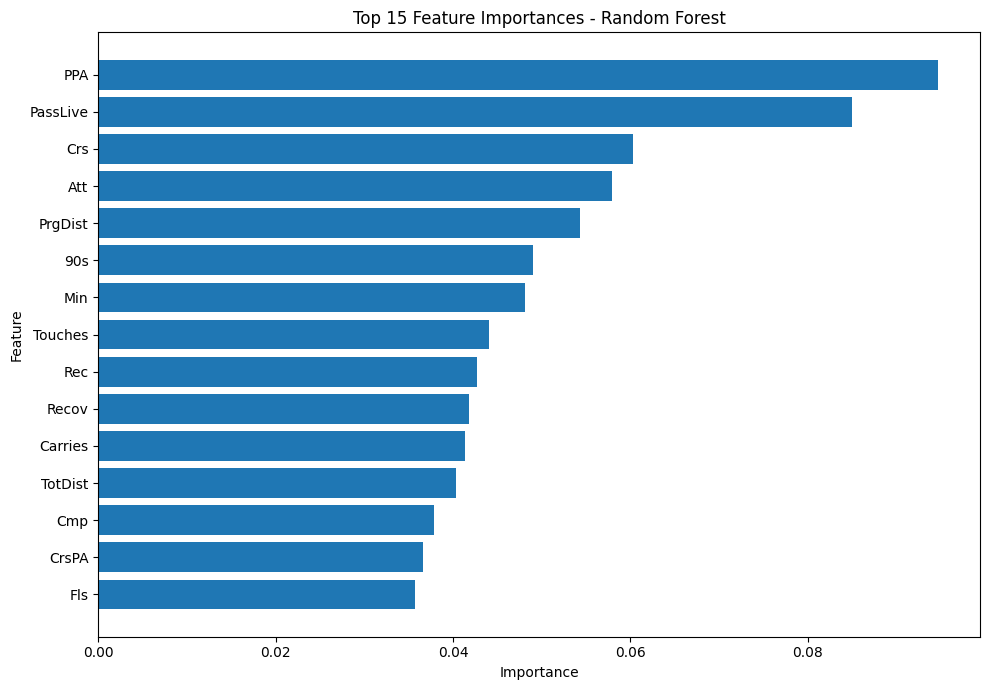

In [ ]:
# ==========================================
# STEP 14: RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 50)

display(rf_importance)

# Plot top 15 features
top_rf = rf_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 15: XGBOOST MODEL
# ==========================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)

print("\nAccuracy:", round(xgb_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Low", "Medium", "High"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        xgb_pred
    )
)

XGBOOST RESULTS

Accuracy: 67.21 %

Classification Report:
              precision    recall  f1-score   support

         Low       0.68      0.57      0.62       446
      Medium       0.64      0.81      0.72       907
        High       0.77      0.50      0.61       440

    accuracy                           0.67      1793
   macro avg       0.70      0.63      0.65      1793
weighted avg       0.68      0.67      0.67      1793


Confusion Matrix:
[[253 192   1]
 [110 731  66]
 [  7 212 221]]


XGBOOST FEATURE IMPORTANCE


,Feature,Importance
0,PPA,0.164647
1,PassLive,0.070444
2,PrgDist,0.053023
3,PassDead,0.048291
4,Min,0.047809
5,90s,0.047163
6,Att,0.046481
7,MP,0.045166
8,Starts,0.040873
9,Crs,0.040769


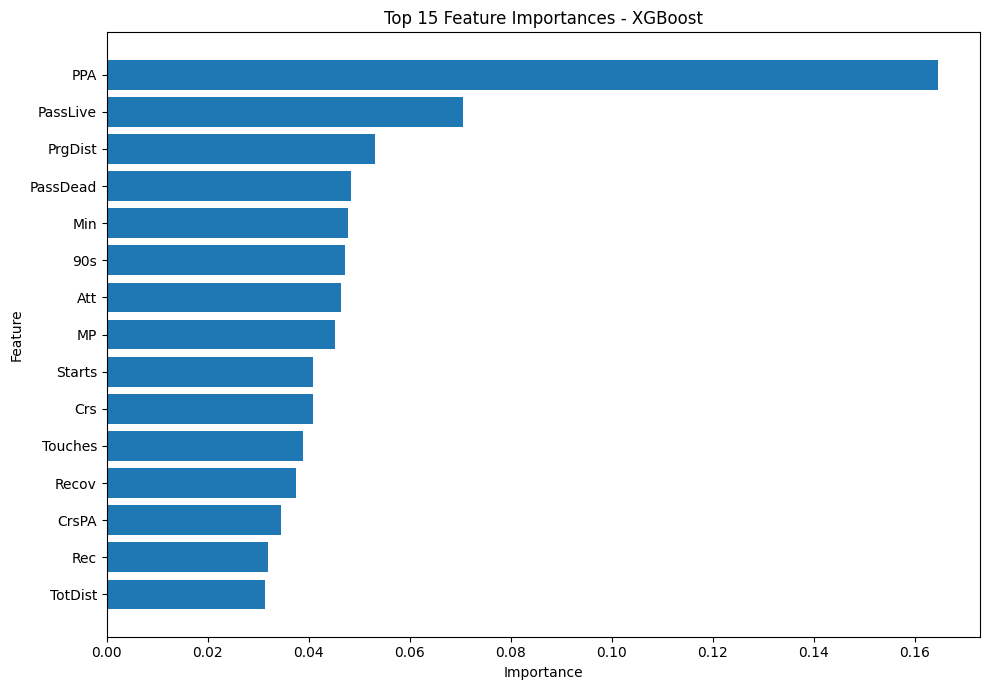

In [ ]:
# ==========================================
# STEP 16: XGBOOST FEATURE IMPORTANCE
# ==========================================

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort from highest to lowest
xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("XGBOOST FEATURE IMPORTANCE")
print("=" * 50)

display(xgb_importance)

# Top 15
top_xgb = xgb_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_xgb["Feature"],
    top_xgb["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE COMPARISON


,Feature,RandomForest,XGBoost,AverageImportance
0,PPA,0.094684,0.164647,0.129665
1,PassLive,0.084932,0.070444,0.077688
2,PrgDist,0.054361,0.053023,0.053692
3,Att,0.057918,0.046481,0.052200
4,Crs,0.060344,0.040769,0.050556
5,90s,0.049040,0.047163,0.048101
6,Min,0.048148,0.047809,0.047978
7,PassDead,0.035667,0.048291,0.041979
8,Touches,0.044049,0.038812,0.041431
9,Recov,0.041819,0.037524,0.039671


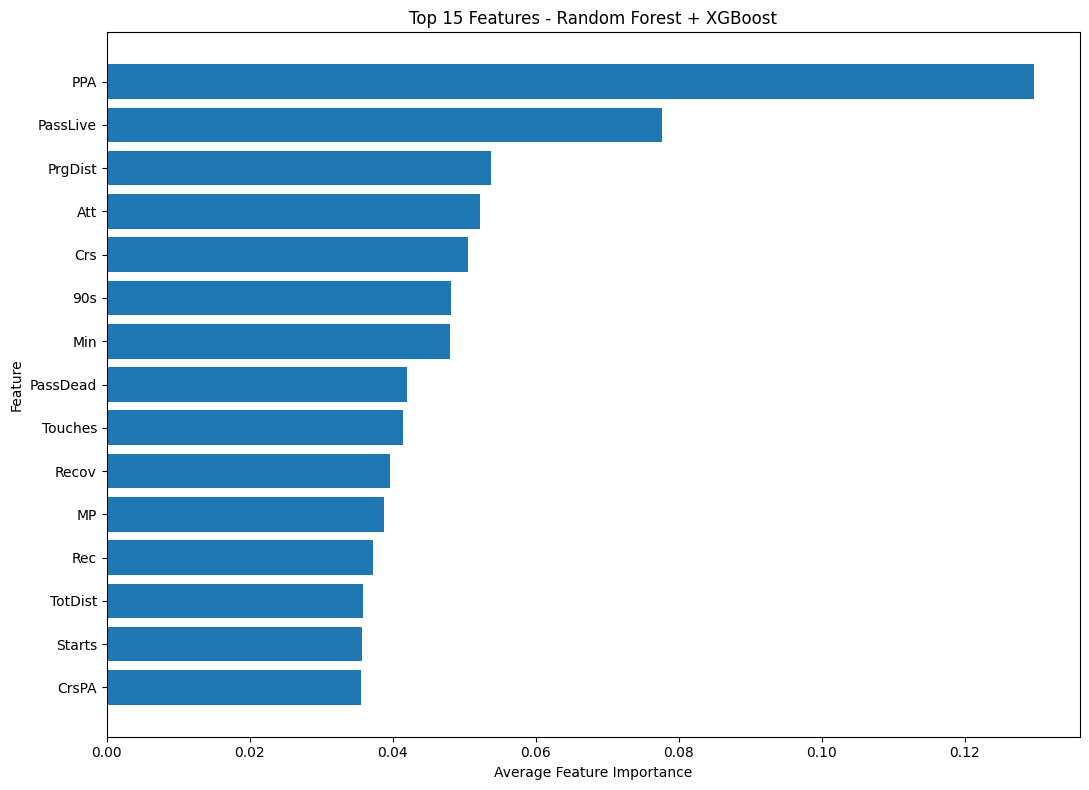

In [ ]:
# ==========================================
# STEP 17: RANDOM FOREST vs XGBOOST
# FEATURE IMPORTANCE COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Feature": X_train.columns,
    "RandomForest": rf_model.feature_importances_,
    "XGBoost": xgb_model.feature_importances_
})

# Add average importance
comparison["AverageImportance"] = (
    comparison["RandomForest"] +
    comparison["XGBoost"]
) / 2

# Sort by average importance
comparison = comparison.sort_values(
    "AverageImportance",
    ascending=False
).reset_index(drop=True)

print("FEATURE IMPORTANCE COMPARISON")
print("=" * 60)

display(comparison)

# Top 15 common features
top_comparison = comparison.head(15).copy()

# Plot
top_plot = top_comparison.sort_values(
    "AverageImportance"
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_plot["Feature"],
    top_plot["AverageImportance"]
)

plt.xlabel("Average Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features - Random Forest + XGBoost"
)

plt.tight_layout()
plt.show()

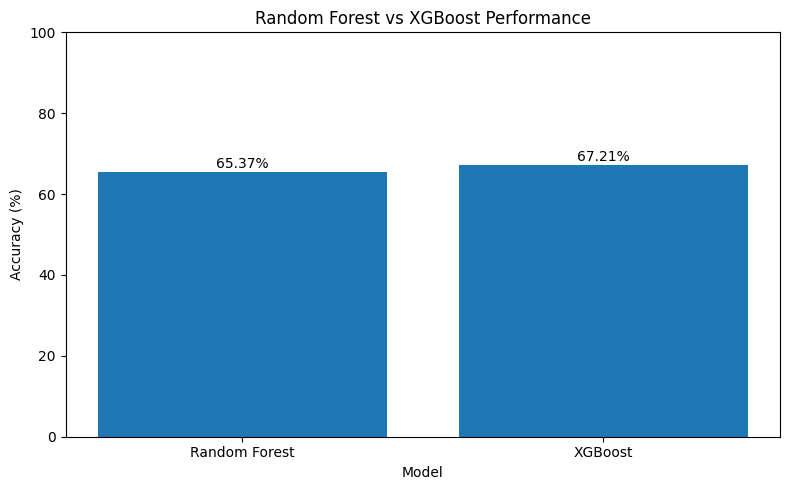

In [ ]:
# ==========================================
# STEP 18: MODEL PERFORMANCE COMPARISON
# ==========================================

models = ["Random Forest", "XGBoost"]
accuracies = [rf_accuracy * 100, xgb_accuracy * 100]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Random Forest vs XGBoost Performance")

plt.ylim(0, 100)

# Display values on bars
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()